# PRISEC-IV — Benchmark Results Analysis

This notebook loads, cleans, and visualizes the four benchmark phases used
in the PRISEC-IV 
1. **Phase 1** — single ciphers (AES-128/192/256, ChaCha20, SPECK, RECTANGLE, HIGHT)
2. **Phase 2** — ECC key exchange + single cipher
3. **Phase 3** — dual-layer cascades (cipher → cipher)
4. **Phase 4** — ECC key exchange + dual-layer cascade

**Benchmark environment:** 2 vCPU, 1st/2nd-gen Intel Xeon Platinum, 2.50 GHz baseline, x86,
1 GB RAM. Values are therefore useful for *relative* comparison between
configurations.

In [35]:
import os

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

%matplotlib inline

## 2. Configuration

Paths to the four result CSVs, output directory for figures, canonical
size ordering, and shared plotting style

In [36]:
CSV_DIR = "../benchmarks"
OUT_DIR = "figures"
os.makedirs(OUT_DIR, exist_ok=True)

SIZE_ORDER = ["1KB", "5KB", "10KB", "50KB", "100KB", "1MB", "5MB", "10MB", "50MB"]

PALETTE = [
    "#D53E4F",
    "#F46D43",
    "#FDAE61",
    "#FEE08B",
    "#E6F598",
    "#ABDAA4",
    "#66C2A5",
    "#3288BD",
    "#2B4875",
]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "legend.frameon": False,
})

## 3. Load raw data

In [37]:
p1 = pd.read_csv(os.path.join(CSV_DIR, "phase1_results.csv"))
p2 = pd.read_csv(os.path.join(CSV_DIR, "phase2_results.csv"))
p3 = pd.read_csv(os.path.join(CSV_DIR, "phase3_results.csv"))
p4 = pd.read_csv(os.path.join(CSV_DIR, "phase4_results.csv"))

for name, df in [("phase1", p1), ("phase2", p2), ("phase3", p3), ("phase4", p4)]:
    print(f"{name}: {df.shape[0]} rows, columns = {list(df.columns)}")


phase1: 63 rows, columns = ['algorithm', 'data_size', 'enc_ms', 'dec_ms', 'throughput_enc_mbps', 'throughput_dec_mbps', 'latency_us', 'memory_enc_kb', 'memory_dec_kb']
phase2: 54 rows, columns = ['algorithm', 'data_size', 'ecc_ms', 'enc_ms', 'dec_ms', 'throughput_enc_mbps', 'throughput_dec_mbps', 'latency_us', 'memory_enc_kb', 'memory_dec_kb']
phase3: 63 rows, columns = ['cascade', 'data_size', 'enc_ms', 'dec_ms', 'throughput_enc_mbps', 'throughput_dec_mbps', 'latency_us', 'memory_enc_kb', 'memory_dec_kb']
phase4: 45 rows, columns = ['cascade', 'data_size', 'ecc_ms', 'enc_ms', 'dec_ms', 'throughput_enc_mbps', 'throughput_dec_mbps', 'latency_us', 'memory_enc_kb', 'memory_dec_kb']


## 4. Phase 1

### Encryption & Decryption times for all sizes for every single cipher

In [38]:
def fmt_ms(v):
    if pd.isna(v):
        return ""
    if v >= 100:
        return f"{v:.0f}"
    if v >= 1:
        return f"{v:.1f}"
    if v >= 0.01:
        return f"{v:.3f}"
    return f"{v:.4f}"


def bar_chart_with_table(df, category_col, value_col, title, out_name,
                          size_order=SIZE_ORDER, figsize=(13, 8)):
    categories = sorted(df[category_col].unique())
    sizes = [s for s in size_order if s in df["data_size"].unique()]

    n_cat = len(categories)
    x = np.arange(len(sizes))
    total_group_width = 0.82
    bar_width = total_group_width / n_cat

    fig, (ax, tax) = plt.subplots(
        2, 1, figsize=figsize,
        gridspec_kw={"height_ratios": [3.2, 1.6], "hspace": 0.05},
    )

    table_rows, row_colors = [], []
    for i, cat in enumerate(categories):
        sub = df[df[category_col] == cat].set_index("data_size")
        heights = [sub.loc[s, value_col] if s in sub.index else np.nan for s in sizes]
        offset = (i - (n_cat - 1) / 2) * bar_width
        color = PALETTE[i % len(PALETTE)]
        ax.bar(x + offset, heights, width=bar_width * 0.92, color=color,
               edgecolor="white", linewidth=0.4, zorder=3)
        table_rows.append([fmt_ms(h) for h in heights])
        row_colors.append(color)

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xticks(x); ax.set_xticklabels([])
    ax.set_ylabel("Time (ms, log scale)")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)

    tax.axis("off")
    the_table = tax.table(
        cellText=table_rows,
        rowLabels=categories,
        colLabels=sizes,
        rowColours=row_colors,
        cellLoc="center",
        loc="upper center",
        bbox=[0.0, 0.0, 1.0, 1.0],
    )
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(8)

    for (row, col), cell in the_table.get_celld().items():
        if col == -1 and row > 0:
            cell.set_text_props(color="white", fontweight="bold")
        if row == 0:
            cell.set_text_props(fontweight="bold")
        cell.set_edgecolor("white")

    fig.savefig(f"{OUT_DIR}/{out_name}.png", dpi=200, bbox_inches="tight")
    fig.savefig(f"{OUT_DIR}/{out_name}.pdf", bbox_inches="tight")
    plt.show()



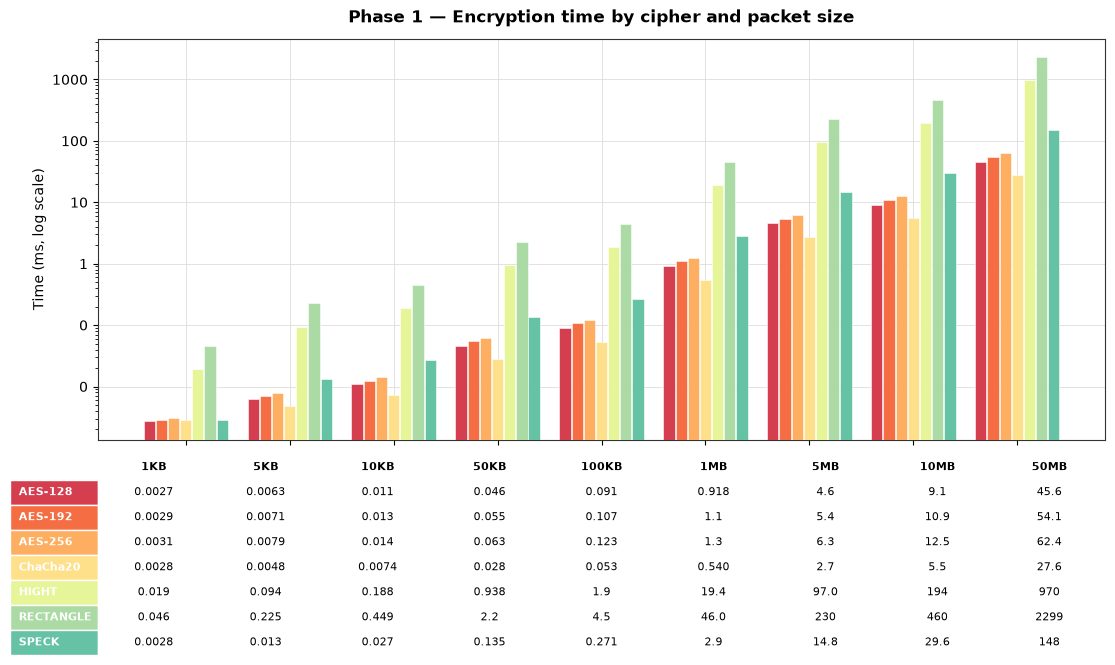

In [39]:
bar_chart_with_table(
    p1, category_col="algorithm", value_col="enc_ms",
    title="Phase 1 — Encryption time by cipher and packet size",
    out_name="fig_A6_phase1_enc_time_table",
)


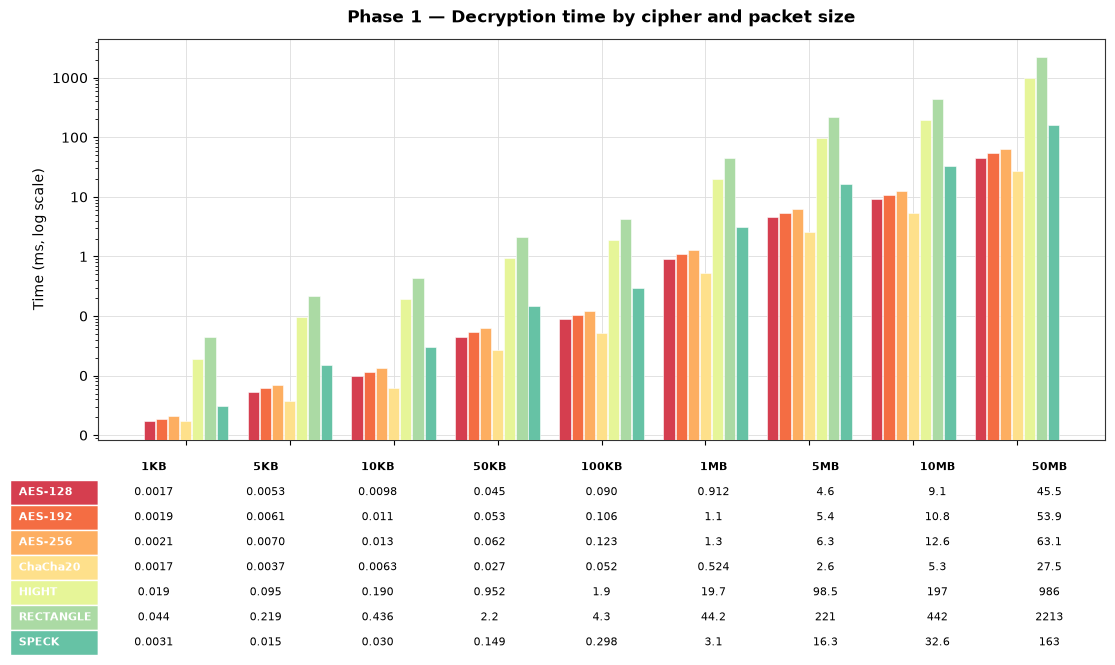

In [40]:
bar_chart_with_table(
    p1, category_col="algorithm", value_col="dec_ms",
    title="Phase 1 — Decryption time by cipher and packet size",
    out_name="fig_A7_phase1_dec_time_table",
)


### Encryption & Decryption throughput for all sizes for every single cipher

In [41]:
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "h"]
LINESTYLES = ["-", "--", "-.", ":", "-", "--", "-.", ":", "-"]

def fmt_mbps(v):
    if pd.isna(v):
        return ""
    if v >= 1000:
        return f"{v:,.0f}"
    if v >= 1:
        return f"{v:.1f}"
    return f"{v:.3f}"

def side_by_side_line_tables(df, category_col, enc_col, dec_col, out_name,
                              value_fmt=fmt_mbps, ylabel="Throughput (Mbps, log scale)",
                              size_order=SIZE_ORDER, figsize=(16, 8.5)):
    categories = sorted(df[category_col].unique())
    sizes = [s for s in size_order if s in df["data_size"].unique()]
    x = np.arange(len(sizes))

    fig, axes = plt.subplots(
        2, 2, figsize=figsize,
        gridspec_kw={"height_ratios": [3.2, 1.6], "hspace": 0.05, "wspace": 0.15},
    )
    (ax_enc, ax_dec), (tax_enc, tax_dec) = axes

    for ax, tax, value_col, subtitle in [
        (ax_enc, tax_enc, enc_col, "Encryption throughput"),
        (ax_dec, tax_dec, dec_col, "Decryption throughput"),
    ]:
        table_rows, row_colors = [], []
        for i, cat in enumerate(categories):
            sub = df[df[category_col] == cat].set_index("data_size")
            values = [sub.loc[s, value_col] if s in sub.index else np.nan for s in sizes]
            color = PALETTE[i % len(PALETTE)]
            ax.plot(x, values, marker=MARKERS[i % len(MARKERS)],
                    linestyle=LINESTYLES[i % len(LINESTYLES)],
                    color=color, markersize=5, linewidth=1.4, zorder=3, label=cat)
            table_rows.append([value_fmt(v) for v in values])
            row_colors.append(color)

        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax.set_xticks(x); ax.set_xticklabels([])
        ax.set_xlim(-0.3, len(sizes) - 0.7)
        ax.set_ylabel(ylabel)
        ax.set_title(subtitle, fontsize=11, fontweight="bold")

        tax.axis("off")
        the_table = tax.table(
            cellText=table_rows, rowLabels=categories, colLabels=sizes,
            rowColours=row_colors, cellLoc="center", loc="upper center",
            bbox=[0.0, 0.0, 1.0, 1.0],
        )
        the_table.auto_set_font_size(False)
        the_table.set_fontsize(6.5)
        for (row, col), cell in the_table.get_celld().items():
            if col == -1 and row > 0:
                cell.set_text_props(color="white", fontweight="bold", fontsize=6.5)
            if row == 0:
                cell.set_text_props(fontweight="bold")
            cell.set_edgecolor("white")

    handles, labels = ax_enc.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(categories),
               bbox_to_anchor=(0.5, 1.04), fontsize=9, frameon=False)
    fig.suptitle("Phase 1 — Encryption vs. decryption throughput by cipher and packet size",
                 fontsize=13, fontweight="bold", y=1.10)

    fig.savefig(f"{OUT_DIR}/{out_name}.png", dpi=200, bbox_inches="tight")
    fig.savefig(f"{OUT_DIR}/{out_name}.pdf", bbox_inches="tight")
    plt.show()

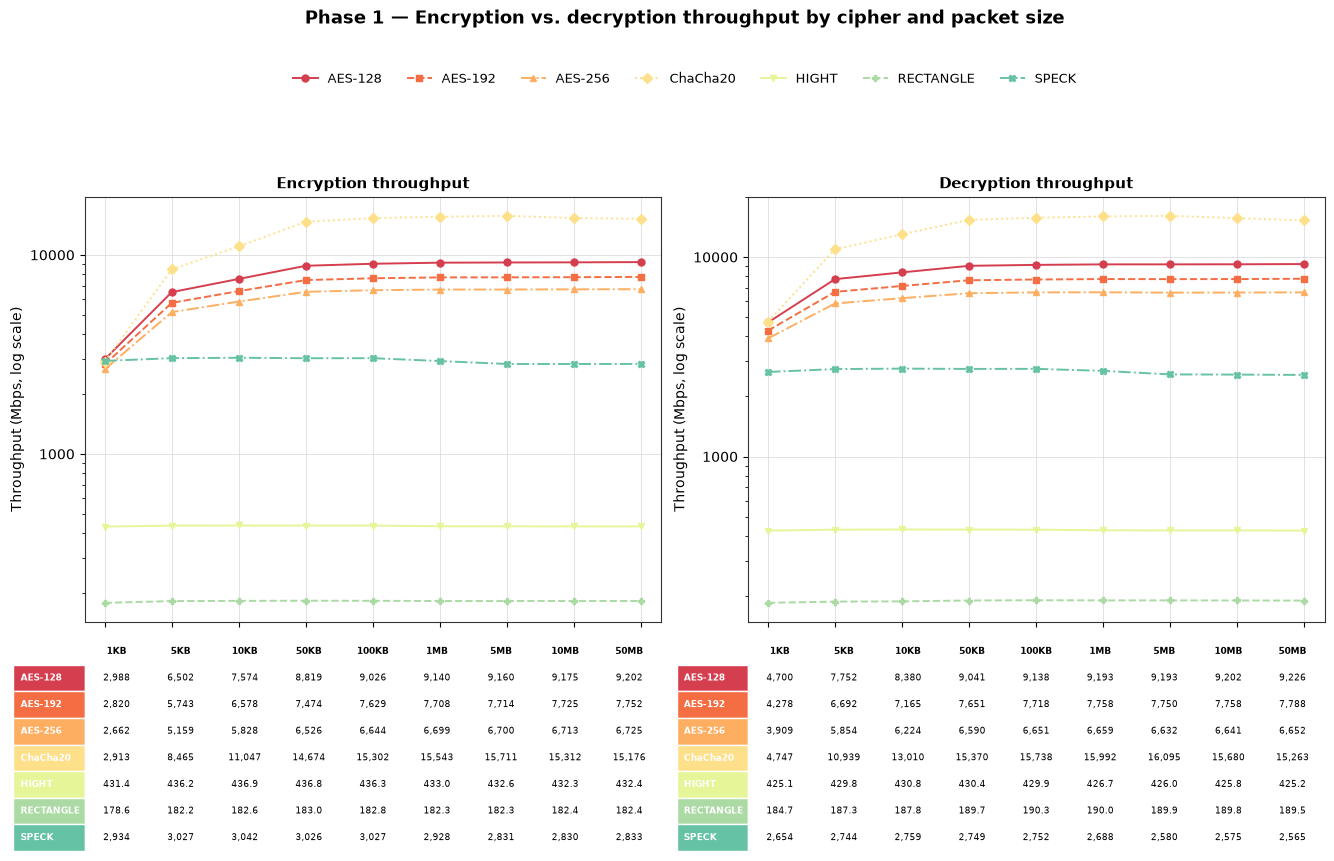

In [42]:
side_by_side_line_tables(
    p1, category_col="algorithm",
    enc_col="throughput_enc_mbps", dec_col="throughput_dec_mbps",
    out_name="fig_phase1_throughput_side_by_side",
)

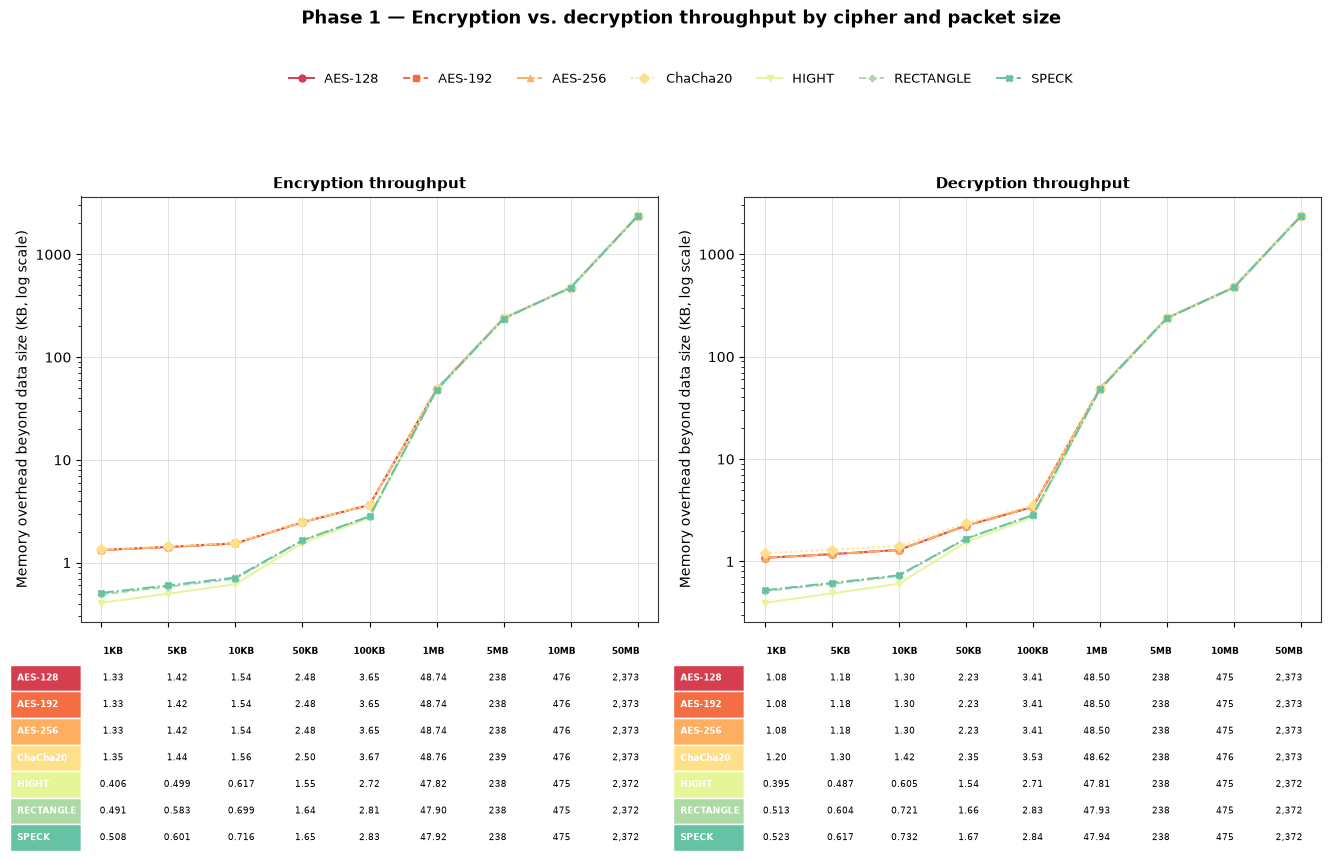

In [43]:
def fmt_kb(v):
    if pd.isna(v):
        return ""
    if v >= 100:
        return f"{v:,.0f}"
    if v >= 1:
        return f"{v:.2f}"
    return f"{v:.3f}"

SIZE_BYTES = {"1KB": 1e3, "5KB": 5e3, "10KB": 1e4, "50KB": 5e4, "100KB": 1e5,
              "1MB": 1e6, "5MB": 5e6, "10MB": 1e7, "50MB": 5e7}
p1["size_kb"] = p1["data_size"].map(SIZE_BYTES) / 1024
p1["mem_overhead_enc_kb"] = p1["memory_enc_kb"] - p1["size_kb"]
p1["mem_overhead_dec_kb"] = p1["memory_dec_kb"] - p1["size_kb"]

side_by_side_line_tables(
    p1, category_col="algorithm",
    enc_col="mem_overhead_enc_kb", dec_col="mem_overhead_dec_kb",
    out_name="fig_phase1_memory_overhead_side_by_side",
    value_fmt=fmt_kb, ylabel="Memory overhead beyond data size (KB, log scale)",
)

In [44]:
def line_chart_with_table(df, category_col, value_col, title, out_name, value_fmt=fmt_ms,
                           ylabel="Time (ms, log scale)", size_order=SIZE_ORDER, figsize=(13, 8)):
    categories = sorted(df[category_col].unique())
    sizes = [s for s in size_order if s in df["data_size"].unique()]
    x = np.arange(len(sizes))

    fig, (ax, tax) = plt.subplots(2, 1, figsize=figsize,
        gridspec_kw={"height_ratios": [3.2, 1.6], "hspace": 0.05})

    table_rows, row_colors, kept_categories = [], [], []
    for i, cat in enumerate(categories):
        sub = df[df[category_col] == cat].set_index("data_size")
        values = [sub.loc[s, value_col] if s in sub.index else np.nan for s in sizes]
        if all(pd.isna(v) for v in values):
            continue  # e.g. ChaCha20 has no latency_us — skip it entirely rather than plot an empty line
        color = PALETTE[i % len(PALETTE)]
        ax.plot(x, values, marker=MARKERS[i % len(MARKERS)], linestyle=LINESTYLES[i % len(LINESTYLES)],
                color=color, markersize=6, linewidth=1.6, zorder=3)
        table_rows.append([value_fmt(v) for v in values])
        row_colors.append(color)
        kept_categories.append(cat)

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xticks(x); ax.set_xticklabels([])
    ax.set_xlim(-0.3, len(sizes) - 0.7)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)

    tax.axis("off")
    the_table = tax.table(cellText=table_rows, rowLabels=kept_categories, colLabels=sizes,
        rowColours=row_colors, cellLoc="center", loc="upper center", bbox=[0.0, 0.0, 1.0, 1.0])
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(8)
    for (row, col), cell in the_table.get_celld().items():
        if col == -1 and row > 0:
            cell.set_text_props(color="white", fontweight="bold")
        if row == 0:
            cell.set_text_props(fontweight="bold")
        cell.set_edgecolor("white")

    fig.savefig(f"{OUT_DIR}/{out_name}.png", dpi=200, bbox_inches="tight")
    fig.savefig(f"{OUT_DIR}/{out_name}.pdf", bbox_inches="tight")
    plt.show()

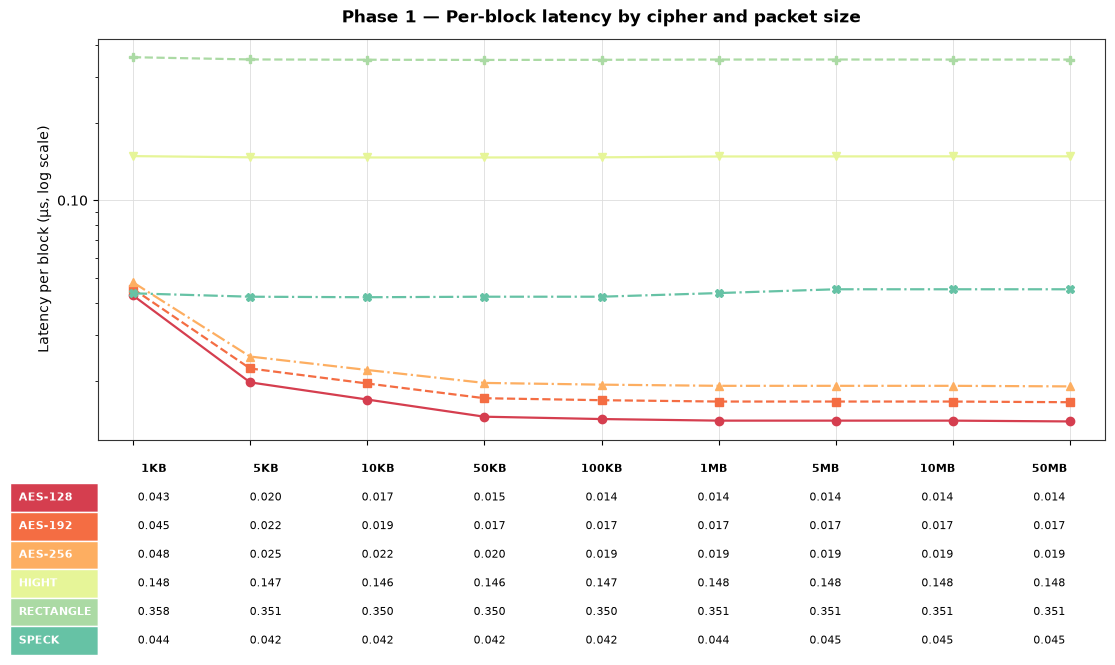

In [45]:
line_chart_with_table(
    p1, category_col="algorithm", value_col="latency_us",
    title="Phase 1 — Per-block latency by cipher and packet size",
    out_name="fig_phase1_latency_table",
    value_fmt=fmt_ms, ylabel="Latency per block (µs, log scale)",
)

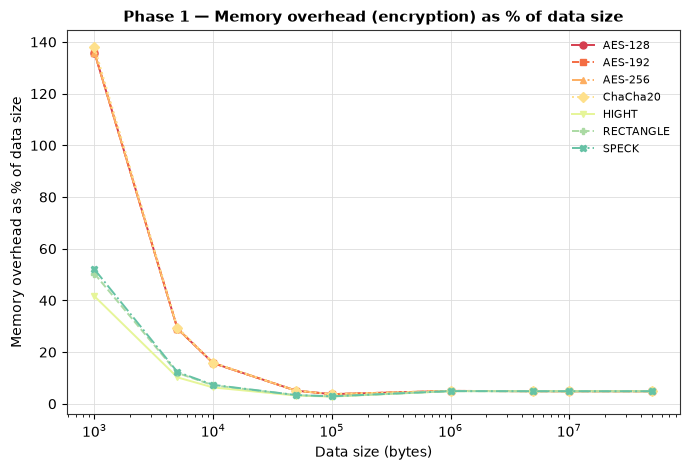

In [46]:
SIZE_BYTES = {"1KB": 1e3, "5KB": 5e3, "10KB": 1e4, "50KB": 5e4, "100KB": 1e5,
              "1MB": 1e6, "5MB": 5e6, "10MB": 1e7, "50MB": 5e7}

p1["size_bytes"] = p1["data_size"].map(SIZE_BYTES)
p1["mem_overhead_enc_pct"] = 100 * p1["mem_overhead_enc_kb"] / p1["size_kb"]

fig, ax = plt.subplots(figsize=(7, 4.8))
algos = sorted(p1["algorithm"].unique())
for i, algo in enumerate(algos):
    sub = p1[p1.algorithm == algo].sort_values("size_bytes")
    ax.plot(sub.size_bytes, sub.mem_overhead_enc_pct, marker=MARKERS[i], linestyle=LINESTYLES[i],
            color=PALETTE[i], markersize=5, linewidth=1.4, label=algo)
ax.set_xscale("log")
ax.set_xlabel("Data size (bytes)")
ax.set_ylabel("Memory overhead as % of data size")
ax.set_title("Phase 1 — Memory overhead (encryption) as % of data size", fontsize=11, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_phase1_mem_overhead_pct.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{OUT_DIR}/fig_phase1_mem_overhead_pct.pdf", bbox_inches="tight")
plt.show()

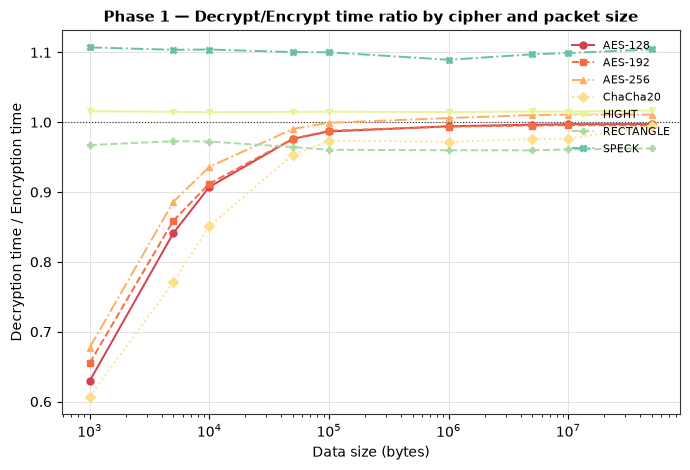

In [47]:
p1["dec_enc_ratio"] = p1["dec_ms"] / p1["enc_ms"]

fig, ax = plt.subplots(figsize=(7, 4.8))
for i, algo in enumerate(algos):
    sub = p1[p1.algorithm == algo].sort_values("size_bytes")
    ax.plot(sub.size_bytes, sub.dec_enc_ratio, marker=MARKERS[i], linestyle=LINESTYLES[i],
            color=PALETTE[i], markersize=5, linewidth=1.4, label=algo)
ax.axhline(1.0, color="#333333", linewidth=0.8, linestyle=":", zorder=1)
ax.set_xscale("log")
ax.set_xlabel("Data size (bytes)")
ax.set_ylabel("Decryption time / Encryption time")
ax.set_title("Phase 1 — Decrypt/Encrypt time ratio by cipher and packet size", fontsize=11, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_phase1_dec_enc_ratio.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{OUT_DIR}/fig_phase1_dec_enc_ratio.pdf", bbox_inches="tight")
plt.show()

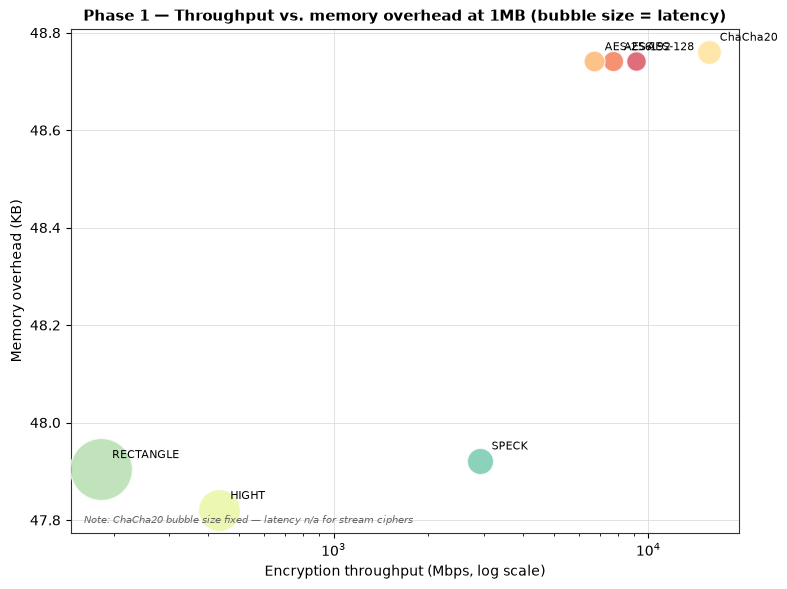

In [48]:
size = "1MB"
sub = p1[p1.data_size == size].copy()

lat_valid = sub.dropna(subset=["latency_us"])
lat_min, lat_max = lat_valid["latency_us"].min(), lat_valid["latency_us"].max()

def bubble_size(v):
    if pd.isna(v):
        return 300  # fixed size for ChaCha20 — no per-block latency applies
    norm = (v - lat_min) / (lat_max - lat_min)
    return 200 + 1800 * norm

fig, ax = plt.subplots(figsize=(8, 6))
for i, (_, row) in enumerate(sub.sort_values("algorithm").iterrows()):
    algo = row["algorithm"]
    color = PALETTE[i % len(PALETTE)]
    ax.scatter(row["throughput_enc_mbps"], row["mem_overhead_enc_kb"],
               s=bubble_size(row["latency_us"]), color=color, alpha=0.75,
               edgecolor="white", linewidth=1, zorder=3, label=algo)
    ax.annotate(algo, (row["throughput_enc_mbps"], row["mem_overhead_enc_kb"]),
                textcoords="offset points", xytext=(8, 8), fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("Encryption throughput (Mbps, log scale)")
ax.set_ylabel("Memory overhead (KB)")
ax.set_title(f"Phase 1 — Throughput vs. memory overhead at {size} (bubble size = latency)",
             fontsize=11, fontweight="bold")
ax.text(0.02, 0.02, "Note: ChaCha20 bubble size fixed — latency n/a for stream ciphers",
        transform=ax.transAxes, fontsize=7.5, style="italic", color="#666666")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_phase1_throughput_vs_memory_bubble.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{OUT_DIR}/fig_phase1_throughput_vs_memory_bubble.pdf", bbox_inches="tight")
plt.show()